In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def backtest(return_data, quarter_weights):
    return quarter_weights.groupby(by='quarter').apply(lambda x: compute_weighted_return(return_data, x))

def compute_weighted_return(return_data, group):
    quarter = group.name
    data = return_data.loc[return_data['quarter'] == quarter, :].copy()
    data.drop('quarter', axis=1, inplace=True)
    group = group.set_index('stock')
    return (group['weight'] * data).sum(axis=1)



In [2]:
import pandas as pd
re_data = pd.read_csv('all_stock_returns.csv')
re_data['交易日期'] = pd.to_datetime(re_data['交易日期'], format='%Y-%m-%d')
re_data = re_data[re_data['交易日期' ]>= '2017-01-01'].reset_index()
re_data.set_index('交易日期', inplace=True)
re_data.fillna(0, inplace=True)
re_data.drop('index', axis=1, inplace=True)
re_data['沪深300'] = re_data['沪深300'].str.rstrip('%').astype(float)
q_data = re_data.resample('Q').apply(lambda x: ((1 + x/100).prod() - 1)*100)
q_data.index = q_data.index.to_period('Q')
q_data.rename_axis('quarter', axis=0, inplace=True)
q_data.reset_index(inplace=True)
q_data.to_csv('quarter_return.csv', index=False)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_319876\787503626.py:9: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_data = re_data.resample('Q').apply(lambda x: ((1 + x/100).prod() - 1)*100)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_319876\787503626.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  q_data.reset_index(inplace=True)


In [ ]:
def visualize_all(avg_return):
    avg_return['quarter'] = avg_return['quarter'].astype(str)

    # Plot 1: Quarterly Returns
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    fig1.patch.set_facecolor('black')   # Set entire canvas background to black
    ax1.set_facecolor('black')          # Set plot area background to black

    ax1.plot(avg_return['quarter'], avg_return['nlp_return'], label='NLP Strategy',
             color='#FF6B6B', linewidth=2.5, marker='o')
    ax1.plot(avg_return['quarter'], avg_return['HS300Index'], label='HS300Index',
             color='#4ECDC4', linewidth=2.5, marker='s')
    ax1.axhline(y=0, color='white', linestyle='--', alpha=0.7)
    ax1.set_title('Quarterly Return', color='white')
    ax1.set_ylabel('Return (%)', color='white')
    # Format legend after plotting curves
    legend = ax1.legend(facecolor='black', edgecolor='white')   # Legend background black, border white
    for text in legend.get_texts():
        text.set_color("white")   # Set legend text to white

    ax1.grid(True, alpha=0.3, color='white')
    plt.xticks(rotation=45, ha='right', color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()

    # Plot 2: Cumulative Returns
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    fig2.patch.set_facecolor('black')
    ax2.set_facecolor('black')

    ax2.plot(avg_return['quarter'], avg_return['nlp_cum_return'], label='NLP Strategy (Cumulative)',
             color='#FF6B6B', linewidth=2.5, marker='o')
    ax2.plot(avg_return['quarter'], avg_return['HS300_cum_return'], label='HS300Index (Cumulative)',
             color='#4ECDC4', linewidth=2.5, marker='s')
    ax2.set_title('Cumulative Compounded Return', color='white')
    ax2.set_ylabel('Cumulative Return', color='white')
    # Format legend after plotting curves
    legend = ax2.legend(facecolor='black', edgecolor='white')   # Legend background black, border white
    for text in legend.get_texts():
        text.set_color("white")   # Set legend text to white
    ax2.grid(True, alpha=0.3, color='white')
    plt.xticks(rotation=45, ha='right', color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_319876\1666145431.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return quarter_weights.groupby(by='quarter').apply(lambda x: compute_weighted_return(return_data, x))


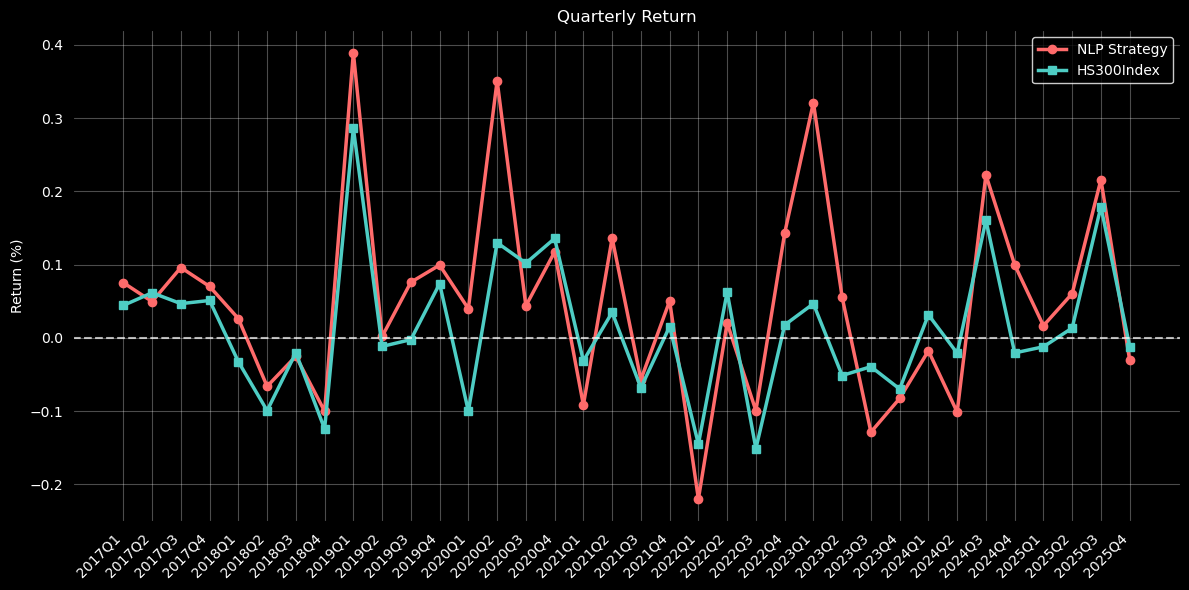

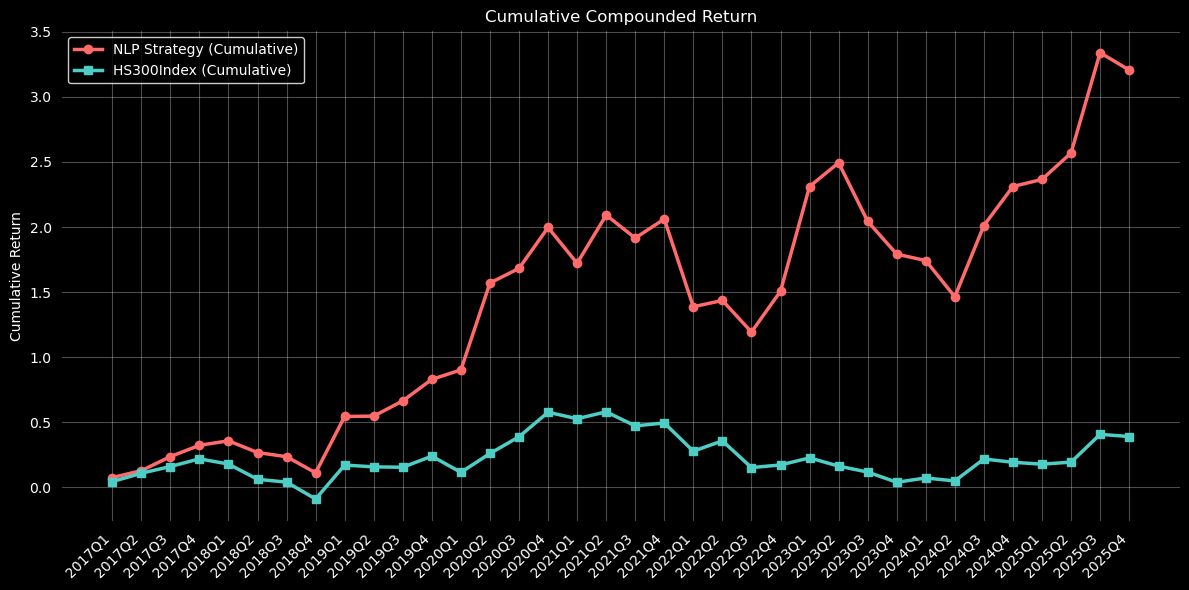

📊 Total Cumulative Returns
NLP Strategy - Total Return: 320.63%
CSI300 Index - Total Return: 39.05%
📈 Portfolio Performance Metrics
NLP Strategy - Sharpe Ratio: 0.3648
NLP Strategy - Information Ratio: 0.4456
CSI300 Index - Sharpe Ratio: 0.1426
CSI300 Index - Information Ratio: 0.0000


In [ ]:
q_data = pd.read_csv('quarter_return.csv')
q_data['quarter'] = pd.PeriodIndex(q_data['quarter'], freq='Q')
hs_data = q_data[['quarter', '沪深300']].copy()
hs_data.rename(columns={'沪深300': 'HS300Index'}, inplace=True)
q_data.drop('沪深300', axis=1, inplace=True)

weights = pd.read_csv('quarterly_weights_sentiment.csv')
weights['quarter'] = pd.PeriodIndex(weights['quarter'].str.replace('_', ''), freq='Q')
weights['stock'] = weights['stock'].astype(str).str.zfill(6)

avg_return = backtest(q_data, weights)
avg_return = avg_return.droplevel(1)
avg_return.name = 'nlp_return'
avg_return = avg_return.reset_index()

avg_return = avg_return.merge(hs_data, on='quarter', how='outer')

# Convert percentage to decimal (if original data is in percentage)
avg_return['nlp_return'] = avg_return['nlp_return'] / 100
avg_return['HS300Index'] = avg_return['HS300Index'] / 100

# Calculate cumulative compounded returns
avg_return['nlp_cum_return'] = (1 + avg_return['nlp_return']).cumprod() - 1
avg_return['HS300_cum_return'] = (1 + avg_return['HS300Index']).cumprod() - 1

# Calculate monthly returns (assuming quarterly returns are compounded)
avg_return['nlp_monthly_return'] = (1 + avg_return['nlp_return'])**(1/3) - 1
avg_return['HS300_monthly_return'] = (1 + avg_return['HS300Index'])**(1/3) - 1

# Optional: Save results
# avg_return.to_csv('avg_return.csv', index=True)

# Display visualizations
visualize_all(avg_return)


# === Sharpe Ratio Calculation ===
# NLP Strategy
mean_nlp = avg_return['nlp_return'].mean()
std_nlp = avg_return['nlp_return'].std()
sharpe_nlp = mean_nlp / std_nlp if std_nlp != 0 else np.nan

# CSI300 Index
mean_csi = avg_return['HS300Index'].mean()
std_csi = avg_return['HS300Index'].std()
sharpe_csi = mean_csi / std_csi if std_csi != 0 else np.nan

# === Information Ratio Calculation ===
# NLP Strategy vs CSI300 benchmark
excess_nlp = avg_return['nlp_return'] - avg_return['HS300Index']
mean_excess_nlp = excess_nlp.mean()
std_excess_nlp = excess_nlp.std()
info_ratio_nlp = mean_excess_nlp / std_excess_nlp if std_excess_nlp != 0 else np.nan

# CSI300 benchmark information ratio = 0
info_ratio_csi = 0.0

final_nlp_return = avg_return['nlp_cum_return'].iloc[-1] 
final_csi_return = avg_return['HS300_cum_return'].iloc[-1] 
print("📊 Total Cumulative Returns") 
print(f"NLP Strategy - Total Return: {final_nlp_return:.2%}") 
print(f"CSI300 Index - Total Return: {final_csi_return:.2%}")
print("📈 Portfolio Performance Metrics")
print(f"NLP Strategy - Sharpe Ratio: {sharpe_nlp:.4f}")
print(f"NLP Strategy - Information Ratio: {info_ratio_nlp:.4f}")
print(f"CSI300 Index - Sharpe Ratio: {sharpe_csi:.4f}")
print(f"CSI300 Index - Information Ratio: {info_ratio_csi:.4f}")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_319876\1666145431.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return quarter_weights.groupby(by='quarter').apply(lambda x: compute_weighted_return(return_data, x))


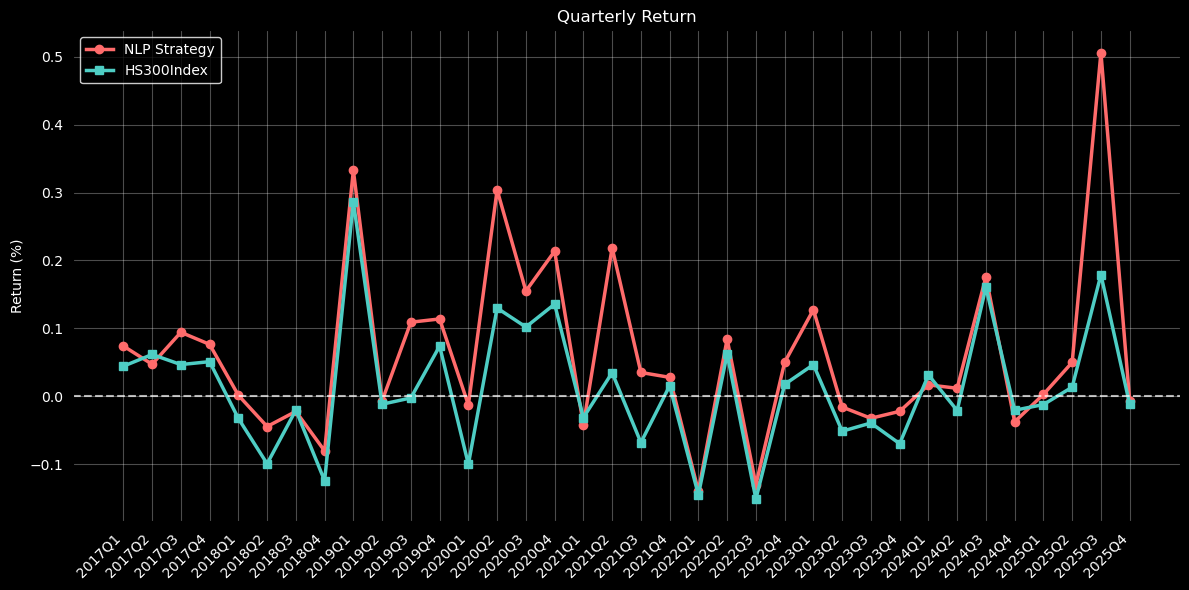

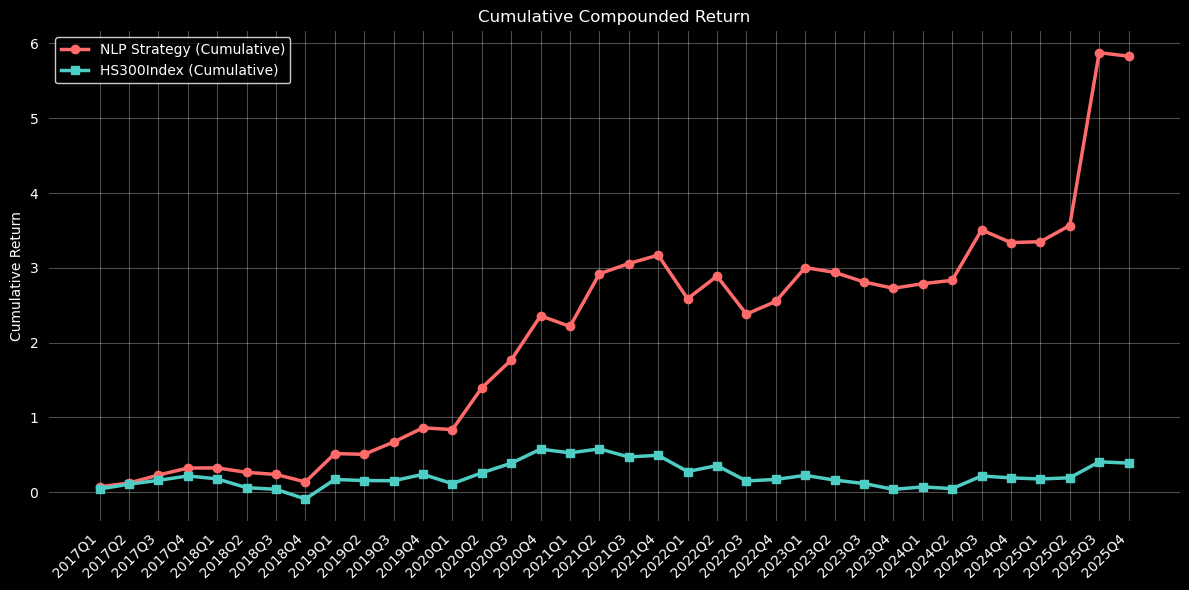

📊 Total Cumulative Returns
NLP Strategy - Total Return: 582.87%
CSI300 Index - Total Return: 39.05%
📈 Portfolio Performance Metrics
NLP Strategy - Sharpe Ratio: 0.4743
NLP Strategy - Information Ratio: 0.7332
CSI300 Index - Sharpe Ratio: 0.1426
CSI300 Index - Information Ratio: 0.0000


In [ ]:
q_data = pd.read_csv('quarter_return.csv')
q_data['quarter'] = pd.PeriodIndex(q_data['quarter'], freq='Q')
hs_data = q_data[['quarter', '沪深300']].copy()
hs_data.rename(columns={'沪深300': 'HS300Index'}, inplace=True)
q_data.drop('沪深300', axis=1, inplace=True)

weights = pd.read_csv('quarterly_weights_inference.csv')
weights['quarter'] = pd.PeriodIndex(weights['quarter'].str.replace('_', ''), freq='Q')
weights['stock'] = weights['stock'].astype(str).str.zfill(6)

avg_return = backtest(q_data, weights)
avg_return = avg_return.droplevel(1)
avg_return.name = 'nlp_return'
avg_return = avg_return.reset_index()

avg_return = avg_return.merge(hs_data, on='quarter', how='outer')

# Convert percentage to decimal (if original data is in percentage)
avg_return['nlp_return'] = avg_return['nlp_return'] / 100
avg_return['HS300Index'] = avg_return['HS300Index'] / 100

# Calculate cumulative compounded returns
avg_return['nlp_cum_return'] = (1 + avg_return['nlp_return']).cumprod() - 1
avg_return['HS300_cum_return'] = (1 + avg_return['HS300Index']).cumprod() - 1

# Calculate monthly returns (assuming quarterly returns are compounded)
avg_return['nlp_monthly_return'] = (1 + avg_return['nlp_return'])**(1/3) - 1
avg_return['HS300_monthly_return'] = (1 + avg_return['HS300Index'])**(1/3) - 1

# Optional: Save results
# avg_return.to_csv('avg_return.csv', index=True)

# Display visualizations
visualize_all(avg_return)


# === Sharpe Ratio Calculation ===
# NLP Strategy
mean_nlp = avg_return['nlp_return'].mean()
std_nlp = avg_return['nlp_return'].std()
sharpe_nlp = mean_nlp / std_nlp if std_nlp != 0 else np.nan

# CSI300 Index
mean_csi = avg_return['HS300Index'].mean()
std_csi = avg_return['HS300Index'].std()
sharpe_csi = mean_csi / std_csi if std_csi != 0 else np.nan

# === Information Ratio Calculation ===
# NLP Strategy vs CSI300 benchmark
excess_nlp = avg_return['nlp_return'] - avg_return['HS300Index']
mean_excess_nlp = excess_nlp.mean()
std_excess_nlp = excess_nlp.std()
info_ratio_nlp = mean_excess_nlp / std_excess_nlp if std_excess_nlp != 0 else np.nan

# CSI300 benchmark information ratio = 0
info_ratio_csi = 0.0

final_nlp_return = avg_return['nlp_cum_return'].iloc[-1] 
final_csi_return = avg_return['HS300_cum_return'].iloc[-1] 
print("📊 Total Cumulative Returns") 
print(f"NLP Strategy - Total Return: {final_nlp_return:.2%}") 
print(f"CSI300 Index - Total Return: {final_csi_return:.2%}")
print("📈 Portfolio Performance Metrics")
print(f"NLP Strategy - Sharpe Ratio: {sharpe_nlp:.4f}")
print(f"NLP Strategy - Information Ratio: {info_ratio_nlp:.4f}")
print(f"CSI300 Index - Sharpe Ratio: {sharpe_csi:.4f}")
print(f"CSI300 Index - Information Ratio: {info_ratio_csi:.4f}")

In [ ]:
import pandas as pd

# Read the weights file
df = pd.read_csv("weight_change_inference.csv")

# Standardize stock codes as strings to avoid type inconsistencies
df['stock'] = df['stock'].astype(str).str.zfill(6)

# Check for duplicate (quarter, stock) pairs
dup_rows = df[df.duplicated(subset=['quarter','stock'], keep=False)]
print("Number of duplicate (quarter, stock) rows:", len(dup_rows))
if len(dup_rows) > 0:
    print("Example duplicate rows:")
    print(dup_rows.head(10))

# Check if stocks appear across multiple quarters (normal, but we can count them)
stock_counts = df.groupby('stock')['quarter'].nunique()
multi_quarters = stock_counts[stock_counts > 1]
print("Number of stocks appearing in multiple quarters:", len(multi_quarters))

# Check if quarter format is consistent
print("Sample quarter unique values:", df['quarter'].unique()[:10])

重复的 (quarter, stock) 行数: 0
跨多个季度出现的股票数: 300
quarter 唯一值示例: ['2017_Q1' '2017_Q2' '2017_Q3' '2017_Q4' '2018_Q1' '2018_Q2' '2018_Q3'
 '2018_Q4' '2019_Q1' '2019_Q2']
